In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm
from matplotlib.animation import FuncAnimation
from sklearn.cluster import DBSCAN
from scipy.spatial.distance import cdist
import math
import random
import pandas as pd
from tqdm.notebook import trange, tqdm

In [2]:
# reproducibility
SEED = 42
np.random.seed(SEED)
random.seed(SEED)

# display settings
plt.rcParams['figure.figsize'] = (7,6)

## Define Biological Gradient Field (BGF) objective functions

### These are the Sphere, Matyas, Ackley, and Easom shapes used in the paper.

In [3]:
def sphere_bgf(x, y, r=0.5):
    # normalized to [0,1] with center at (0,0) and radius r region = 1
    d2 = x**2 + y**2
    val = np.where(d2 <= r**2, 1.0, 1.0 - 0.02 * d2)
    return np.clip(val, 0.0, 1.0)

def matyas_bgf(x, y, r=0.5):
    d2 = x**2 + y**2
    val = np.where(d2 <= r**2, 1.0, 1.0 - 0.26*(d2) - (-0.48*x*y))
    val = val/100.0 + 0.0 + 0.0
    return np.clip(val, 0.0, 1.0)

def ackley_bgf(x, y, r=0.5):
    d2 = x**2 + y**2
    inside = d2 <= r**2
    # standard ackley-ish shaped surface (parameters tuned for visualization)
    a = 4.0/3.0
    b = 10.0
    c = 2*math.pi
    val_out = (a * ( - np.exp(-np.sqrt(2*(x**2+y**2))/b) - np.exp((np.cos(c*x)+np.cos(c*y))/2.0)/np.e + 1.0 ))
    val = np.where(inside, 1.0, val_out)
    val = (val - val.min())/(val.max()-val.min()+1e-9)
    return np.clip(val, 0.0, 1.0)

def easom_bgf(x, y, r=0.5):
    d2 = x**2 + y**2
    inside = d2 <= r**2
    val_out = 0.01 + 0.99 * np.cos(3*x) * np.cos(3*y) * np.exp(-(9*x**2 + 9*y**2))
    val = np.where(inside, 1.0, val_out)
    val = (val - val.min())/(val.max()-val.min()+1e-9)
    return np.clip(val, 0.0, 1.0)

BGF_FUNCTIONS = {
    'Sphere': sphere_bgf,
    'Matyas': matyas_bgf,
    'Ackley': ackley_bgf,
    'Easom': easom_bgf
}

# test plot (demo)
X = np.linspace(-5,5,201)
Y = np.linspace(-5,5,201)
XX, YY = np.meshgrid(X,Y)
ZZ = sphere_bgf(XX, YY, r=1.0)
# plt.imshow(ZZ, origin='lower', extent=[-5,5,-5,5]); plt.colorbar(); plt.title('Sphere BGF (demo)')


## Vascular network generator (simple percolation-like mask)

### Creates a mask of traversable nodes (vessels) inside a 2D region. We'll create a sparse network using random growth from a corner (approx invasion percolation).


In [4]:
def generate_vascular_mask(size=201, occupancy=0.6, fractal_seed=SEED):
    """
    size: grid size (size x size)
    occupancy: proportion of nodes to occupy (i.e., vessels)
    returns: mask (bool array) where True = vessel node
    """
    np.random.seed(fractal_seed)
    strength = np.random.rand(size, size)
    mask = np.zeros((size, size), dtype=bool)
    # start from lower-left corner index (0,0)
    start = (0,0)
    mask[start] = True
    target_nodes = int(occupancy * size * size)
    frontier = [start]
    while mask.sum() < target_nodes and frontier:
        # pick a frontier cell, expand to its lowest strength neighbor
        i,j = random.choice(frontier)
        # neighbors within grid
        nbrs = []
        for di,dj in [(1,0),(-1,0),(0,1),(0,-1)]:
            ni, nj = i+di, j+dj
            if 0 <= ni < size and 0 <= nj < size and not mask[ni,nj]:
                nbrs.append((ni,nj))
        if not nbrs:
            frontier.remove((i,j))
            continue
        # choose neighbor with min strength (simulating invasion percolation)
        nbr = min(nbrs, key=lambda p: strength[p])
        mask[nbr] = True
        frontier.append(nbr)
    return mask

# Example usage:
# vessel_mask = generate_vascular_mask(size=201, occupancy=0.4)
# plt.imshow(vessel_mask, origin='lower'); plt.title('Vascular mask (demo)')


## Nanoswimmer agent class and utilities

### Agents maintain positions, sample BGF in SO mode, and move in DC mode based on magnetic direction.

In [5]:
class NanoSwimmer:
    def __init__(self, pos, idx):
        self.pos = np.array(pos, dtype=float)   
        self.idx = idx
        self.alive = True
        self.fitness = 0.0
        self.path = [tuple(self.pos)]
        self.detected = False

    def record(self):
        self.path.append(tuple(self.pos))

def clip_to_bounds(p, bound=5.0):
    return np.clip(p, -bound, bound)

def sample_bgf_at_positions(func, positions):
    # positions: array of shape (M,2)
    x = positions[:,0]; y = positions[:,1]
    return func(x,y)

def distance(a,b):
    return np.linalg.norm(np.array(a)-np.array(b))

# helper to convert from continuous coords (-5..5) to grid index for vessel mask
def continuous_to_index(p, size=201, bound=5.0):
    x, y = p
    ix = int(((x + bound)/(2*bound)) * (size-1))
    iy = int(((y + bound)/(2*bound)) * (size-1))
    return max(0,min(size-1,ix)), max(0,min(size-1,iy))


## IARS decision functions: gradient approx, elite selection, weighted least squares, DBSCAN chase

### These functions implement the main computational parts of IARS used in DC mode.

In [6]:
def estimate_local_gradient(func, pos, delta=0.05):
    """
    Estimate gradient direction at continuous position pos by finite differences (small offset sampling).
    Returns angle in radians (direction of increasing BGF).
    """
    x,y = pos
    # small offsets
    f0 = func(x,y)
    fx = func(x+delta,y)
    fy = func(x,y+delta)
    gx = (fx - f0) / (delta + 1e-9)
    gy = (fy - f0) / (delta + 1e-9)
    angle = np.arctan2(gy, gx)
    return angle, f0

def get_elite_direction(agents, func, E):
    """
    agents: list of NanoSwimmer
    E: number of elites
    Returns theta_f (foraging angle)
    """
    # compute fitness at current positions
    coords = np.array([a.pos for a in agents])
    vals = sample_bgf_at_positions(func, coords)
    # assign fitness
    for a,v in zip(agents, vals):
        a.fitness = v
    # choose top E
    sorted_agents = sorted(agents, key=lambda a: a.fitness, reverse=True)
    elites = sorted_agents[:max(1,E)]
    # estimate their gradient angles
    angles = []
    weights = []
    for e in elites:
        ang, _ = estimate_local_gradient(func, e.pos)
        angles.append(ang)
        weights.append(e.fitness + 1e-6)
    # weighted least squares on angles — treat angles as vectors
    vecs = np.array([[math.cos(a), math.sin(a)] for a in angles])
    W = np.diag(weights)
    try:
        # weighted average direction
        mean_vec = np.sum((W @ vecs), axis=0) / np.sum(weights)
        theta_f = math.atan2(mean_vec[1], mean_vec[0])
    except Exception as ex:
        theta_f = angles[0]
    return theta_f

def get_chase_direction(agents, func, M):
    """
    Identify disadvantaged (low-fitness) agents, cluster them and compute a chase direction
    using the centroid of a DBSCAN cluster of disadvantaged agents and elite centroid.
    """
    coords = np.array([a.pos for a in agents])
    vals = np.array([a.fitness for a in agents])
    # select M lowest fitness
    idxs = np.argsort(vals)[:max(1,M)]
    low_coords = coords[idxs]
    if len(low_coords) <= 1:
        # fallback
        centroid = np.mean(coords, axis=0)
        direction = math.atan2(centroid[1]-low_coords[0][1], centroid[0]-low_coords[0][0]) if len(low_coords)>0 else 0.0
        return direction
    db = DBSCAN(eps=0.3, min_samples=1).fit(low_coords)
    labels = db.labels_
    # choose largest cluster
    unique, counts = np.unique(labels, return_counts=True)
    main_label = unique[np.argmax(counts)]
    cluster_points = low_coords[labels==main_label]
    cluster_centroid = cluster_points.mean(axis=0)
    # elite centroid
    elites_idx = np.argsort(vals)[-max(1,int(len(agents)*0.2)):]  
    elite_centroid = coords[elites_idx].mean(axis=0)
    direction = math.atan2(elite_centroid[1] - cluster_centroid[1], elite_centroid[0] - cluster_centroid[0])
    return direction


## Main simulation loop: SO/DC alternation, movement mechanics, and metrics collection.

### This is the core runnable simulation.


In [7]:
def run_iars_simulation(
    bgf_name='Ackley',
    n_agents=60,
    grid_size=201,
    vessel_occupancy=0.5,
    iterations=80,
    so_steps=10,
    so_step_length=0.05,
    v_ma=0.5,   
    elite_rate=0.35,
    disadvantage_ratio=0.2,
    target_radius=0.5,
    target_center=(0.0,0.0),
    bound=5.0
):
    func = BGF_FUNCTIONS[bgf_name]
    # generate vascular mask
    vessel_mask = generate_vascular_mask(size=grid_size, occupancy=vessel_occupancy)
    # initialize agents in injection box (bottom-left region)
    agents = []
    init_x_min, init_x_max = -5.0, -4.0
    init_y_min, init_y_max = -5.0, -4.0
    for i in range(n_agents):
        x = np.random.uniform(init_x_min, init_x_max)
        y = np.random.uniform(init_y_min, init_y_max)
        agents.append(NanoSwimmer((x,y), i))
    # metrics trackers
    detection_history = []
    time_history = []
    # main loop: alternate SO (sensing) and DC (drive) phases
    for it in range(iterations):
        for a in agents:
            if not a.alive: continue
            K = so_steps
            for k in range(K):
                flow_bias = np.array([0.02, 0.02])  # small drift
                jitter = np.random.normal(scale=so_step_length, size=2)
                a.pos = clip_to_bounds(a.pos + flow_bias + jitter, bound=bound)
            a.record()
            # check detection
            if np.linalg.norm(a.pos - np.array(target_center)) <= target_radius:
                a.detected = True
                a.alive = False
        # Collect BGF observations (external tracking system)
        coords = np.array([a.pos for a in agents if a.alive])
        if coords.size == 0:
            detection_history.append(n_agents)
            break
        vals = sample_bgf_at_positions(func, coords)
        # assign fitness back to alive agents
        alive_agents = [a for a in agents if a.alive]
        for a,v in zip(alive_agents, vals):
            a.fitness = v

        E = max(1, int(elite_rate * len(alive_agents)))
        theta_f = get_elite_direction(alive_agents, func, E)
        M = max(1, int(disadvantage_ratio * len(alive_agents)))
        theta_c = get_chase_direction(alive_agents, func, M)
        thetas = []
        for a in alive_agents:
            theta_i, _ = estimate_local_gradient(func, a.pos)
            thetas.append(theta_i)
        thetas = np.array(thetas)
        # distances (squared errors) from theta_f and theta_c (circular distance)
        def circ_err(a,b):
            diff = (a - b + np.pi) % (2*np.pi) - np.pi
            return diff**2
        delta_et = np.sum([circ_err(t, theta_f) for t in thetas])
        delta_lf = np.sum([circ_err(t, theta_c) for t in thetas])
        pet = delta_lf / (delta_et + delta_lf + 1e-9)
        plf = delta_et / (delta_et + delta_lf + 1e-9)
        # choose behavior each DC: for simplicity choose probabilistically once per DC
        behavior = 'forage' if random.random() < plf else 'chase'
        if behavior == 'forage':
            drive_theta = theta_f
        else:
            drive_theta = theta_c

        dt = 0.5  
        step = v_ma * dt
        for a in alive_agents:
            # move in drive direction, plus small noise and vessel constraint (we don't implement complicated vessel steering; just prevent leaving bound)
            noise = np.random.normal(scale=0.02, size=2)
            move = np.array([math.cos(drive_theta), math.sin(drive_theta)]) * step + noise
            a.pos = clip_to_bounds(a.pos + move, bound=bound)
            a.record()
            # detect if reached tumor
            if np.linalg.norm(a.pos - np.array(target_center)) <= target_radius:
                a.detected = True
                a.alive = False
        detected_count = sum(1 for a in agents if a.detected)
        detection_history.append(detected_count)
        if (it + 1) % 10 == 0:
            print(f"Iteration {it + 1}/{iterations} - Detected: {detected_count}/{n_agents}")

    return agents, vessel_mask, func, detection_history

# Quick run (short)
agents, vessel_mask, func, detection_history = run_iars_simulation(
    bgf_name='Ackley',
    n_agents=60,
    iterations=60,
    so_steps=8,
    v_ma=0.8,
    elite_rate=0.35,
    disadvantage_ratio=0.2,
    target_radius=0.6
)


Iteration 10/60 - Detected: 0/18
Iteration 20/60 - Detected: 0/18
Iteration 30/60 - Detected: 0/18
Iteration 40/60 - Detected: 0/18
Iteration 50/60 - Detected: 0/18
Iteration 60/60 - Detected: 0/18


## Visualize final agent paths and detection progress

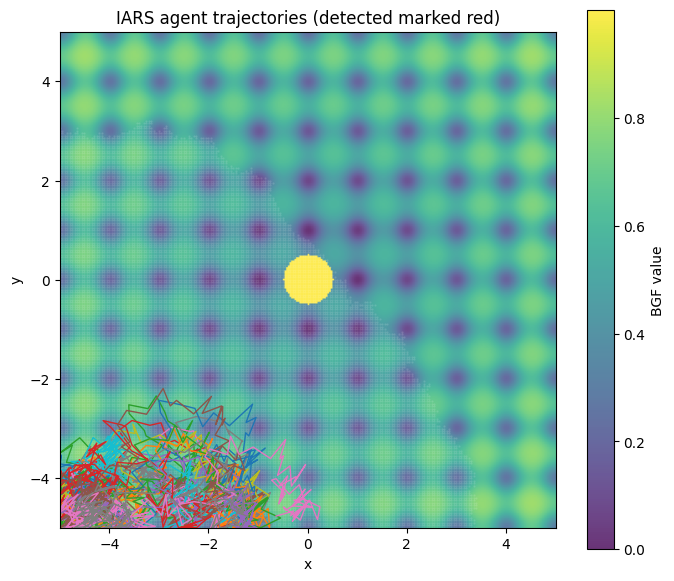

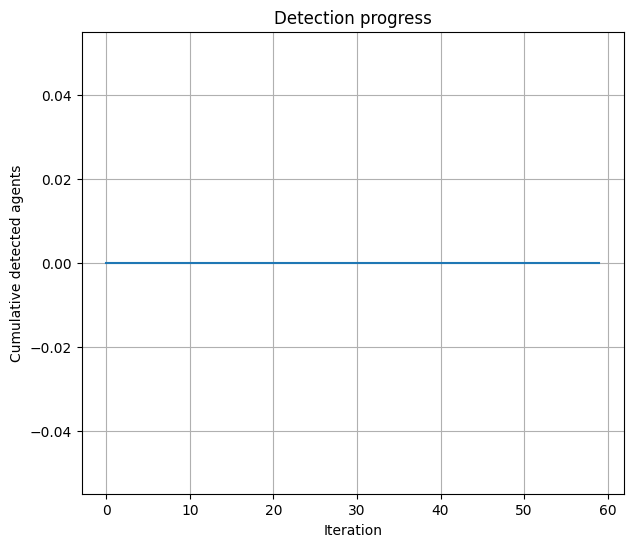

In [8]:
def plot_paths(agents, func, vessel_mask=None, bound=5.0, cmap='viridis', title='IARS paths'):
    # background BGF
    X = np.linspace(-bound, bound, 301)
    Y = np.linspace(-bound, bound, 301)
    XX, YY = np.meshgrid(X,Y)
    ZZ = func(XX, YY)
    fig, ax = plt.subplots(figsize=(8,7))
    im = ax.imshow(ZZ, origin='lower', extent=[-bound,bound,-bound,bound], cmap='viridis', alpha=0.8)
    plt.colorbar(im, ax=ax, label='BGF value')
    # plot vessel mask if provided (downsampled)
    if vessel_mask is not None:
        # plot some vessel points
        mask = vessel_mask
        idxs = np.argwhere(mask)
        # map idxs to continuous coords
        coords = (idxs / (mask.shape[0]-1)) * (2*bound) - bound
        ax.scatter(coords[:,1], coords[:,0], s=0.3, c='white', alpha=0.12)
    # plot agent paths
    for a in agents:
        path = np.array(a.path)
        ax.plot(path[:,0], path[:,1], linewidth=1)
        if a.detected:
            ax.scatter([path[-1,0]],[path[-1,1]], marker='*', s=80, c='red')
    ax.set_xlim(-bound,bound); ax.set_ylim(-bound,bound)
    ax.set_title(title)
    ax.set_xlabel('x'); ax.set_ylabel('y')
    plt.show()

plot_paths(agents, func, vessel_mask=vessel_mask, title='IARS agent trajectories (detected marked red)')
# detection curve
plt.plot(detection_history); plt.xlabel('Iteration'); plt.ylabel('Cumulative detected agents'); plt.title('Detection progress'); plt.grid(True)


## Simple baseline comparisons (BF: brute force along flow; WP-PSO simplified)

### These are simplified proxies to compare broad behavior — not full reproduced SP-GD/WP-PSO.

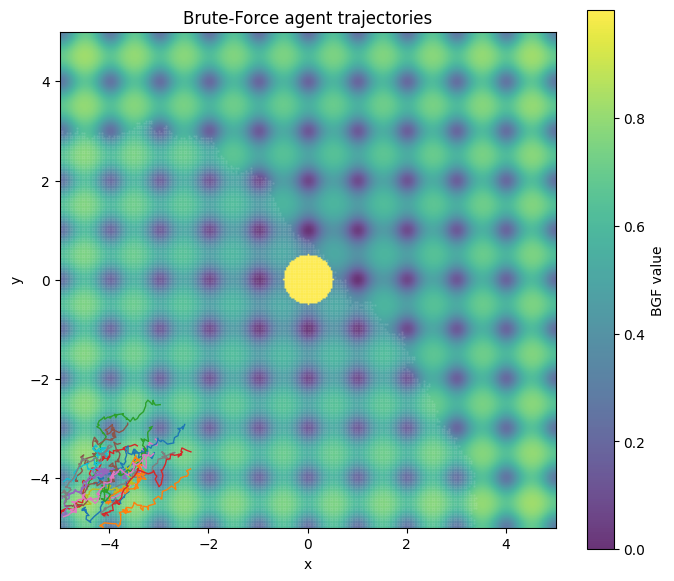

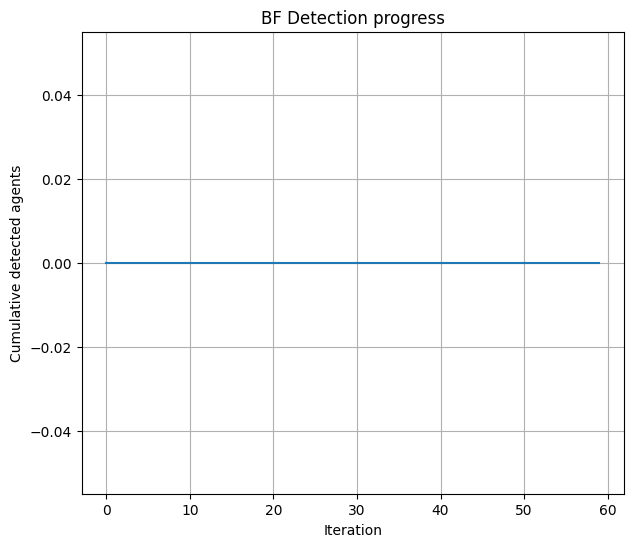

In [9]:
def run_bruteforce(n_agents=60, iterations=60, flow_vec=np.array([0.02,0.02]), bound=5.0, target_radius=0.6, target_center=(0.0,0.0)):
    agents = [NanoSwimmer((np.random.uniform(-5,-4), np.random.uniform(-5,-4)), i) for i in range(n_agents)]
    detection_history = []
    for it in range(iterations):
        for a in agents:
            if not a.alive: continue
            jitter = np.random.normal(scale=0.05, size=2)
            a.pos = clip_to_bounds(a.pos + flow_vec + jitter, bound=bound)
            a.record()
            if np.linalg.norm(a.pos - np.array(target_center)) <= target_radius:
                a.detected = True; a.alive=False
        detection_history.append(sum(1 for a in agents if a.detected))
    return agents, detection_history

# run BF
bf_agents, bf_hist = run_bruteforce()
plot_paths(bf_agents, func, vessel_mask=vessel_mask, title='Brute-Force agent trajectories')
plt.plot(bf_hist); plt.xlabel('Iteration'); plt.ylabel('Cumulative detected agents'); plt.title('BF Detection progress'); plt.grid(True)


## Save a summary (simple printed results) and next steps guidance



In [10]:
print("Summary:")
print(f"Total agents: {len(agents)}")
print("Detected agents (IARS):", sum(1 for a in agents if a.detected))
print("Detected agents (BF):", sum(1 for a in bf_agents if a.detected))

# Next steps suggestions for your project (you can include these in report)
notes = [
    "1) Tune parameters: elite_rate, disadvantage_ratio, v_ma, SO/DC durations.",
    "2) Run multiple experiments (e.g., 1000 runs) to compute average detection rate, targeting efficiency, and time - like the paper.",
    "3) Implement SP-GD and WP-PSO exactly (paper gives exact update rules) and compare.",
    "4) Add richer vascular constraints: restrict movement to vessel mask nodes by snapping positions to nearest vessel node.",
    "5) Produce charts like paper: detection success rate across objective functions, targeting efficiency, and boxplots of targeting times."
]
for n in notes:
    print(n)


Summary:
Total agents: 18
Detected agents (IARS): 0
Detected agents (BF): 0
1) Tune parameters: elite_rate, disadvantage_ratio, v_ma, SO/DC durations.
2) Run multiple experiments (e.g., 1000 runs) to compute average detection rate, targeting efficiency, and time - like the paper.
3) Implement SP-GD and WP-PSO exactly (paper gives exact update rules) and compare.
4) Add richer vascular constraints: restrict movement to vessel mask nodes by snapping positions to nearest vessel node.
5) Produce charts like paper: detection success rate across objective functions, targeting efficiency, and boxplots of targeting times.


## 3D BGF Surface Visualization

Use this cell to compare the 3D biological gradient field shapes without embedding the simulator UI inside the notebook.

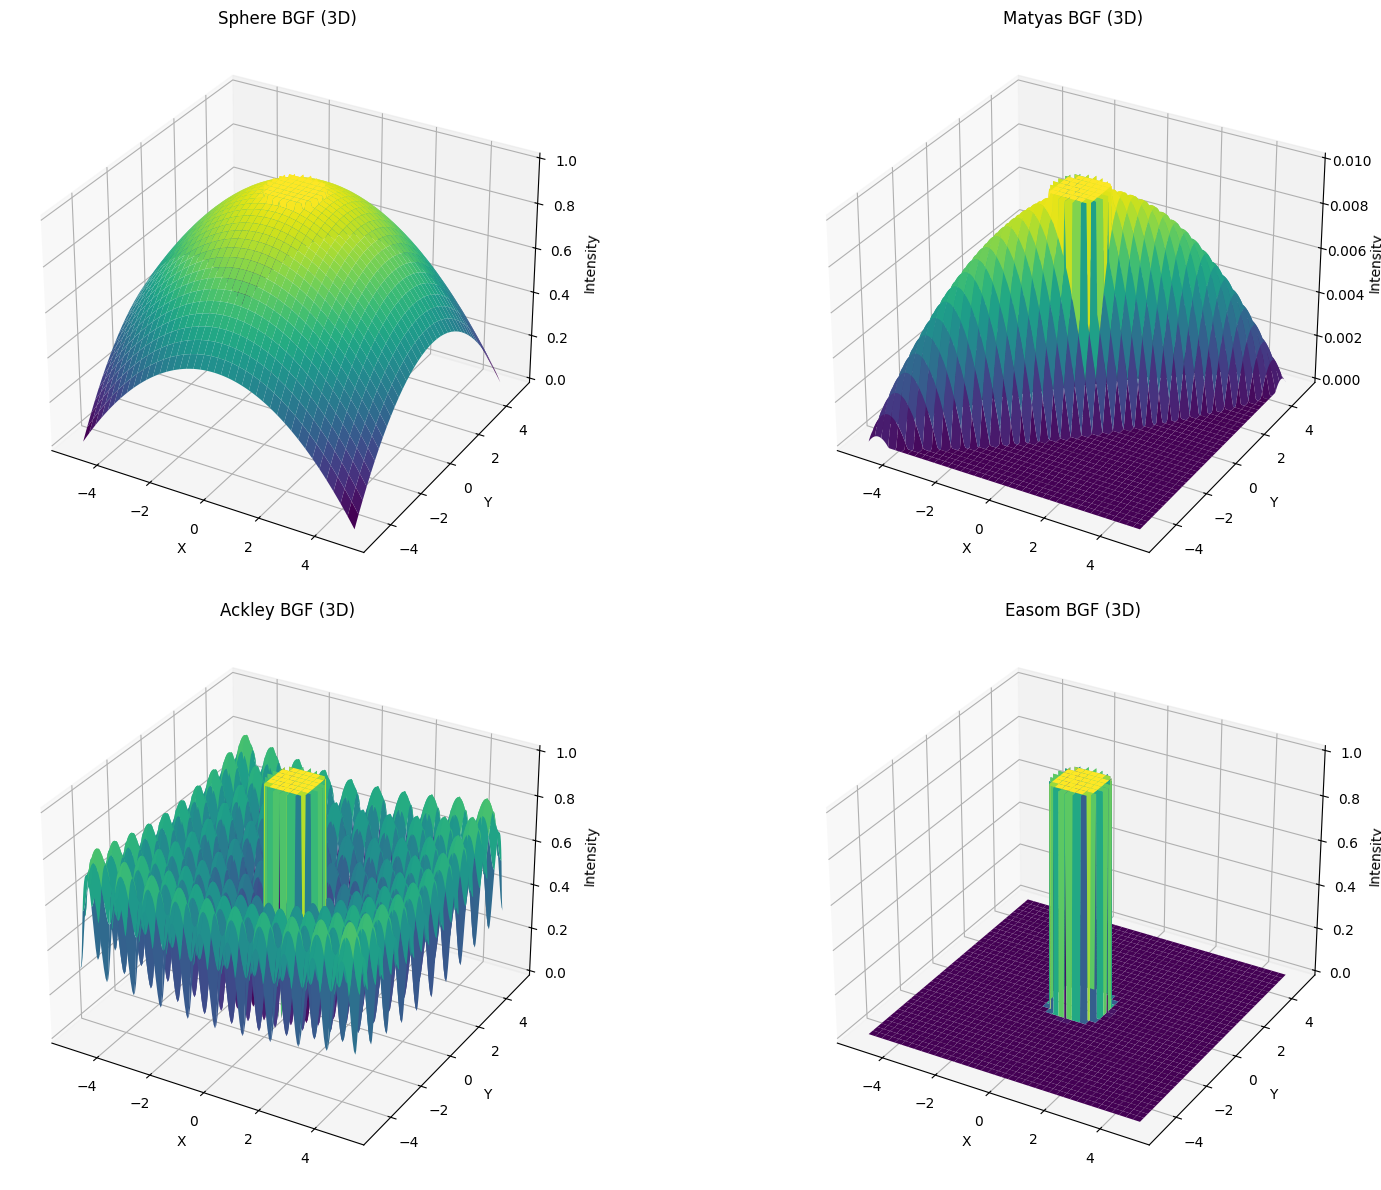

In [11]:
from mpl_toolkits.mplot3d import Axes3D

X = np.linspace(-5, 5, 201)
Y = np.linspace(-5, 5, 201)
XX, YY = np.meshgrid(X, Y)

fig = plt.figure(figsize=(18, 12))
for i, name in enumerate(BGF_FUNCTIONS.keys(), 1):
    func = BGF_FUNCTIONS[name]
    Z = func(XX, YY, r=1.0)
    ax = fig.add_subplot(2, 2, i, projection='3d')
    ax.plot_surface(XX, YY, Z, cmap='viridis')
    ax.set_title(f'{name} BGF (3D)')
    ax.set_xlabel('X')
    ax.set_ylabel('Y')
    ax.set_zlabel('Intensity')

plt.tight_layout()
plt.show()


## BGF Movement Differentiation Analysis

This section shows how different BGF functions change nanoswimmer movement behavior, not just the target position.

The comparison below keeps the same swarm settings and only changes the BGF function. It measures:
- detection rate
- mean final distance to the target
- mean path length
- mean straightness ratio (displacement / path length)
- mean turning angle per step

Interpretation: lower straightness and higher turning angle mean the swimmers are taking more curved or oscillatory routes.

In [ ]:
def compute_path_metrics(agents, target_center=(0.0, 0.0)):
    target = np.array(target_center, dtype=float)
    rows = []
    for agent in agents:
        path = np.array(agent.path, dtype=float)
        if len(path) < 2:
            path_length = 0.0
            turning_mean = 0.0
        else:
            steps = np.diff(path, axis=0)
            step_lengths = np.linalg.norm(steps, axis=1)
            path_length = float(np.sum(step_lengths))
            if len(steps) >= 2:
                headings = np.arctan2(steps[:, 1], steps[:, 0])
                heading_diff = (np.diff(headings) + np.pi) % (2 * np.pi) - np.pi
                turning_mean = float(np.mean(np.abs(heading_diff)))
            else:
                turning_mean = 0.0

        displacement = float(np.linalg.norm(path[-1] - path[0])) if len(path) else 0.0
        final_distance = float(np.linalg.norm(path[-1] - target)) if len(path) else 0.0
        straightness = displacement / (path_length + 1e-9) if path_length > 0 else 0.0
        rows.append({
            'detected': int(agent.detected),
            'final_distance': final_distance,
            'path_length': path_length,
            'straightness': straightness,
            'turning_angle': turning_mean,
            'final_fitness': float(agent.fitness),
        })
    return pd.DataFrame(rows)

def compare_bgf_movements(bgf_names=None, n_agents=60, iterations=60, so_steps=8, v_ma=0.8, elite_rate=0.35, disadvantage_ratio=0.2, target_radius=0.6, seed=42):
    bgf_names = bgf_names or list(BGF_FUNCTIONS.keys())
    summaries = []
    results = {}

    for idx, bgf_name in enumerate(bgf_names):
        run_seed = seed + idx
        np.random.seed(run_seed)
        random.seed(run_seed)
        agents, vessel_mask, func, detection_history = run_iars_simulation(
            bgf_name=bgf_name,
            n_agents=n_agents,
            iterations=iterations,
            so_steps=so_steps,
            v_ma=v_ma,
            elite_rate=elite_rate,
            disadvantage_ratio=disadvantage_ratio,
            target_radius=target_radius,
        )

        metrics = compute_path_metrics(agents)
        summary = {
            'BGF': bgf_name,
            'Detection %': round(100.0 * metrics['detected'].mean(), 2),
            'Mean Final Distance': round(metrics['final_distance'].mean(), 4),
            'Mean Path Length': round(metrics['path_length'].mean(), 4),
            'Mean Straightness': round(metrics['straightness'].mean(), 4),
            'Mean Turning Angle': round(metrics['turning_angle'].mean(), 4),
            'Mean Final Fitness': round(metrics['final_fitness'].mean(), 4),
            'Final Detected Count': int(metrics['detected'].sum()),
        }
        summaries.append(summary)
        results[bgf_name] = {
            'agents': agents,
            'vessel_mask': vessel_mask,
            'func': func,
            'detection_history': detection_history,
            'metrics': metrics,
        }

    return pd.DataFrame(summaries), results

def plot_bgf_movement_comparison(results, summary_df, bound=5.0, save_dir=None):
    if save_dir is not None:
        from pathlib import Path
        save_dir = Path(save_dir)
        save_dir.mkdir(parents=True, exist_ok=True)
    bgf_names = list(summary_df['BGF'])
    fig, axes = plt.subplots(2, 2, figsize=(16, 14))
    axes = axes.flatten()

    for ax, bgf_name in zip(axes, bgf_names):
        data = results[bgf_name]
        func = data['func']
        X = np.linspace(-bound, bound, 220)
        Y = np.linspace(-bound, bound, 220)
        XX, YY = np.meshgrid(X, Y)
        ZZ = func(XX, YY)
        ax.imshow(ZZ, origin='lower', extent=[-bound, bound, -bound, bound], cmap='viridis', alpha=0.85)

        for agent in data['agents'][:18]:
            path = np.array(agent.path)
            ax.plot(path[:, 0], path[:, 1], linewidth=0.9, alpha=0.8)

        detected_paths = [np.array(agent.path)[-1] for agent in data['agents'] if agent.detected]
        if detected_paths:
            detected_paths = np.array(detected_paths)
            ax.scatter(detected_paths[:, 0], detected_paths[:, 1], c='red', s=25, label='Detected')

        ax.scatter(0.0, 0.0, c='white', edgecolors='black', marker='*', s=140, label='Target')
        ax.set_title(f'{bgf_name} movement pattern')
        ax.set_xlim(-bound, bound)
        ax.set_ylim(-bound, bound)
        ax.set_xlabel('x')
        ax.set_ylabel('y')

    handles, labels = axes[0].get_legend_handles_labels()
    if handles:
        axes[0].legend(loc='upper left')
    plt.tight_layout()
    if save_dir is not None:
        fig.savefig(save_dir / 'bgf_movement_patterns.png', dpi=220, bbox_inches='tight')
    plt.show()

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    for bgf_name in bgf_names:
        axes[0].plot(results[bgf_name]['detection_history'], linewidth=2, label=bgf_name)
    axes[0].set_title('Detection progress by BGF')
    axes[0].set_xlabel('Iteration')
    axes[0].set_ylabel('Detected swimmers')
    axes[0].grid(True, alpha=0.3)
    axes[0].legend()

    summary_df.plot(x='BGF', y=['Mean Final Distance', 'Mean Path Length'], kind='bar', ax=axes[1], rot=0)
    axes[1].set_title('Distance and path length')
    axes[1].set_ylabel('Value')
    axes[1].grid(True, axis='y', alpha=0.3)

    summary_df.plot(x='BGF', y=['Mean Straightness', 'Mean Turning Angle'], kind='bar', ax=axes[2], rot=0)
    axes[2].set_title('Route shape metrics')
    axes[2].set_ylabel('Value')
    axes[2].grid(True, axis='y', alpha=0.3)

    plt.tight_layout()
    if save_dir is not None:
        fig.savefig(save_dir / 'bgf_metric_comparison.png', dpi=220, bbox_inches='tight')
    plt.show()

bgf_summary_df, bgf_results = compare_bgf_movements()
from pathlib import Path
export_dir = Path('bgf_exports')
export_dir.mkdir(parents=True, exist_ok=True)
bgf_summary_df.to_csv(export_dir / 'bgf_summary.csv', index=False)
try:
    from IPython.display import display
    display(bgf_summary_df)
except Exception:
    print(bgf_summary_df.to_string(index=False))
plot_bgf_movement_comparison(bgf_results, bgf_summary_df, save_dir=export_dir)
print(f'Report exports saved in: {export_dir}')


## How To Explain The Difference Between BGFs

Use the table and plots above in your report or demo like this:

- If a BGF gives higher straightness, swimmers are following a smoother and more direct route.
- If a BGF gives higher turning angle, swimmers are changing direction more often, so the field is producing more curved or oscillatory motion.
- If mean final distance is lower, that BGF is guiding the swarm closer to the target region by the end of the run.
- If detection progress rises faster, that BGF is helping the swarm find the target earlier.

So the BGF does not only change the target cell position. It changes the gradient landscape, and that changes how smoothly, directly, or slowly the nanoswimmers move across the grid.

## Interactive Simulator

The simulator UI has been moved out of this notebook into `nanoswimmer_simulation.py` so the notebook stays lighter and easier to run.

Run the simulator separately from the project folder with `python nanoswimmer_simulation.py`.
If port 5000 is busy on your Mac, run it with `PORT=5051 python nanoswimmer_simulation.py` instead.

Keep this notebook for parameter setup, analysis, graphs, and 3D BGF visualization.